## Module 2: Introducing DataFrames

### Pandas DataFrames Basics - Part 2
- Helpful Jupyter features
- Importing a CSV dataset
- Selecting multiple columns
- Counting True values in a Boolean series
- Filtering rows with Boolean masks
- Using AND and OR operators
- Why and when to use .copy
- Sorting a dataframe by one or more columns

In [ ]:
import pandas as pd

* Download the dataset from the link in the workbook
* Run below code, select and uplaod your file in Colab

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mpg.csv to mpg.csv


#mpg means miles per gallon

This dataset contains 234 observations about different car models and their characteristics, primarily focusing on fuel economy. It will help learners practice data exploration, cleaning, aggregation, and visualization using pandas.



| Column         | Description                                                 |
| -------------- | ----------------------------------------------------------- |
| `manufacturer` | Car manufacturer (e.g., Audi, Ford, Toyota)                 |
| `model`        | Specific model name                                         |
| `displ`        | Engine displacement in litres (numeric)                     |
| `year`         | Year of the model                                           |
| `cyl`          | Number of cylinders in the engine                           |
| `trans`        | Type of transmission (e.g., automatic, manual)              |
| `drv`          | Drive type: front-wheel (f), rear-wheel (r), or 4-wheel (4) |
| `cty`          | City miles per gallon (MPG) – a measure of fuel efficiency  |
| `hwy`          | Highway MPG                                                 |
| `fl`           | Fuel type (e.g., p = premium, r = regular, d = diesel)      |
| `class`        | Vehicle class (e.g., compact, SUV, pickup)                  |


In [ ]:
# pd.read_csv reads a comma-separated value file and returns a dataframe
mpg = pd.read_csv("mpg.csv")
mpg

In [ ]:
# Showing the object.tab autocomplete option
# Type the variable that's already been evaluated in memory
# This works with imported modules, too
# Type .
# Then type the <Tab> character
mpg.count?

In [ ]:
# Pulling up the docstring for a method
mpg.head?

In [ ]:
# .tail looks at the last records of a pandas object (series or datafram)
mpg.tail(3)

In [ ]:
# The square brackets on the dataframe can accept a list of column names
columns_of_interest = ["displ", "cty", "hwy"]
mpg[columns_of_interest].head()

In [ ]:
# You'll also see the same result with double square brackets
mpg[["cty", "hwy"]].head()

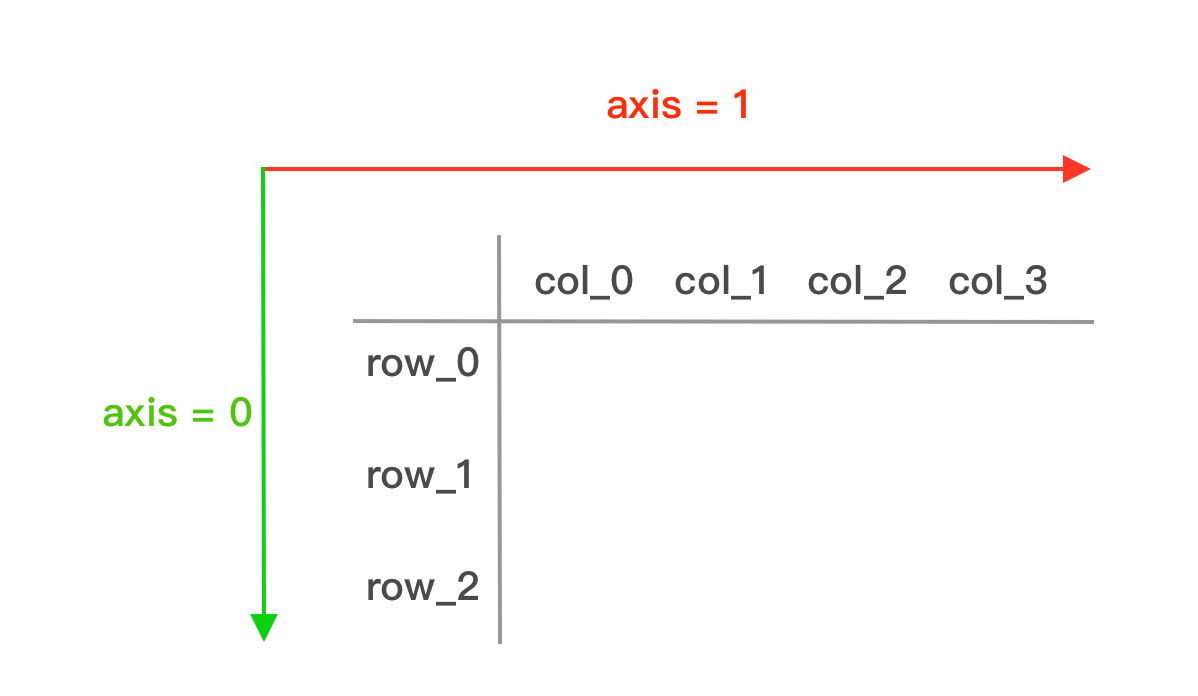

In [ ]:
# Our functions like .mean, .sum, .median, min/max evaluate an entire column, by default
# There's a default argument in .mean() that's axis=0 (which means column)
mpg[["cty", "hwy"]].mean(axis=0)

In [ ]:
mpg[["cty", "hwy"]].head()

In [ ]:
# axis=1 means execute the .mean on each row, row-wise execution
mpg[["cty", "hwy"]].mean(axis=1).head()

In [ ]:
# axis=1 calculates the row-wise average
mpg["average_mileage"] = mpg[["cty", "hwy"]].mean(axis=1)
mpg.head()

In [ ]:
# value_counts shows unique values and their distribution
mpg.cyl.value_counts()

In [ ]:
# Using Boolean Series to answer questions
# How many audis in the dataset
# True works as a 1, False works as 0
(mpg.manufacturer == "audi").sum()

In [ ]:
# What proportion of engines are 4 cylinders?
(mpg.cyl == 4).mean()

In [ ]:
# Using Boolean Series to filter a dataframe
mpg[mpg.cyl == 5]

In [ ]:
# You can mix and match the columns used to generate Booleans, the Boolean values don't care
mpg[(mpg.model == "maxima") | (mpg.cyl == 5)]

In [ ]:
# AND limits options. Both predicates must be true
mpg[(mpg["class"] == "midsize") & (mpg["displ"] < 2)]

In [ ]:
original_df = pd.DataFrame({"x": [1, 2, 3]})
original_df

In [ ]:
# Be careful assigning Python collections like this...
# This works the same way with lists, dictionaries, and many other collection objects
new_df = original_df

In [ ]:
original_df["y"] = original_df.x * 100
original_df

In [ ]:
new_df

In [ ]:
# Use .copy to make a proper copy of a dataframe
new_df = original_df.copy()
new_df

In [ ]:
original_df["z"] = 5000
original_df

In [ ]:
# The new df was created from a copy and avoids future mutation to the original dataframe
new_df

In [ ]:
# Sorting by a single column
mpg.sort_values(by=["average_mileage"], ascending=False, ignore_index=True).head()

In [ ]:
# Sorting by multiple columns
mpg.sort_values(by=["hwy", "cty"], ascending=False, ignore_index=True).head()

In [ ]:
# Updating the dataframe to store the sorted values
# Use inplace=True or reassign the dataframe variable (not both)
mpg.sort_values(by="displ", ascending=False, ignore_index=True, inplace=True)
mpg.head()

In [ ]:
mpg[["cyl", "displ"]].corr()

In [ ]:
mpg[["cyl", "displ", "average_mileage"]].corr()
#higher the number of cylinders lower the average mileage
#higher the displace lower the average mileage


In [ ]:
# top 5 car with highest average milage
mpg.nlargest(5,"average_mileage")

In [ ]:
# top 5 car with lowest average milage
mpg.nsmallest(5,"average_mileage")

# create another columns to represent mpg cty, hwy  and average mileage as miles per litre

In [ ]:
# miles per gallon to miles per litre conversion
mpg_to_mpl = 0.425144

In [ ]:
# creating new column for city
mpg['city_mpl'] = mpg['cty'] * mpg_to_mpl

In [ ]:
# display top mpl
mpg.nlargest(5,"city_mpl")

In [ ]:
# creating new column for highway
mpg['hwy_mpl'] = mpg['hwy'] * mpg_to_mpl

In [ ]:
# creating new column for average
mpg['avg_mpl'] = ((mpg['cty'] + mpg['hwy']) / 2) * mpg_to_mpl

In [ ]:
mpg.nlargest(5,"avg_mpl")

In [ ]:
mpg.nsmallest(1,"avg_mpl")

In [ ]:
# 500 miles in UK with avg_mpl of 15
# 500/15 = 33 litres *1.5 = £50
# 500 miles avg_mpl 5
# 500/5 = 100litres = £150

## Additional Resources
- [Pandas Cheat Sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)
- [Pandas Comparison to Spreadsheets](https://pandas.pydata.org/docs/dev/getting_started/comparison/comparison_with_spreadsheets.html)
- [Pandas Comparison to SQL](https://pandas.pydata.org/docs/dev/getting_started/comparison/comparison_with_sql.html)

## Exercises
- Create a new column named `is_automatic` that holds a Boolean if that given vehicle is an automatic transmition or not.
- Use the `is_automatic` column to sum up the number of automatic vehicles in this dataset.
- Write the pandas code to determine what percentage of the vehicles are subcompacts?
- Combined fuel economy is a weighted average of the city value by 55% and the highway value by 45%. Use arithmetic operators to add a new column named `fuel_economy` to the `mpg` dataframe.
- Use Boolean masking to find all of the vehicles with a `fuel_economy` above the median `fuel_economy`.



In [ ]:
#Create a new column named is_automatic that holds a Boolean if that given vehicle is an automatic transmition or not.
mpg['is_automatic'] = mpg['trans'].str.lower().str.contains('auto') # convert to lower case as a safety measure


In [ ]:
# Use the `is_automatic` column to sum up the number of automatic vehicles in this dataset.
#mpg.is_automatic.value_counts() #First checking total true false values
mpg['is_automatic'].sum()

np.int64(157)

In [ ]:
# Write the pandas code to determine what percentage of the vehicles are subcompacts?
# how many car as subcompacts?
# total number of cars

#(mpg['class'] == 'subcompact').mean() * 100
mpg['class'].eq('subcompact').mean() * 100 # method for better redability



np.float64(14.957264957264957)

In [ ]:
# Create a `fuel_economy` column. Fuel economy is a weighted average of the city value by 55% and the highway value by 45%

mpg['fuel_economy'] = mpg['cty'] * 0.55 + mpg['hwy'] * 0.45


In [ ]:
# Use Boolean masking to find all of the vehicles with a `fuel_economy` above the median `fuel_economy`.

mpg[mpg['fuel_economy'] > mpg['fuel_economy'].median()]